# Imports, loading data and exploring the baseline


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# importing the cleaned data file (done in sql)
data_path = Path("C:/Users/Khush/Desktop/Supply Chain Project/supply-chain-delivery-optimizer/sql/data-1789208865909.csv")

df = pd.read_csv(data_path)

print(df.columns)

# Verify the view dataset loaded properly
print(f"Total Rows Loaded: {len(df):,}")
print("First 3 rows:")
print(df[["order_id", "shipping_mode", "market", "total_sales", "is_late"]].head(3))

print(" \n Target Variable Distribution (0 = On Time, 1 = Late):")
print(df["is_late"].value_counts(normalize=True))

Index(['order_id', 'order_item_id', 'customer_id', 'order_date',
       'shipping_date', 'shipping_mode', 'scheduled_days', 'actual_days',
       'delay_days', 'delivery_status', 'late_delivery_risk', 'is_late',
       'sla_met_flag', 'market', 'order_region', 'order_country', 'order_city',
       'category_name', 'product_name', 'quantity', 'product_price',
       'total_sales', 'profit', 'shipping_risk_tier'],
      dtype='object')
Total Rows Loaded: 180,519
First 3 rows:
   order_id   shipping_mode        market  total_sales  is_late
0     77202  Standard Class  Pacific Asia       327.75        0
1     75939  Standard Class  Pacific Asia       327.75        1
2     75938  Standard Class  Pacific Asia       327.75        0
 
 Target Variable Distribution (0 = On Time, 1 = Late):
is_late
1    0.548291
0    0.451709
Name: proportion, dtype: float64


# Data Visualisation (EDA)

Before transforming our variables for machine learning, we need to inspect the underlying distributions, identify potential class imbalances in our target (`is_late`), and understand how key supply chain features influence delivery delays.

## Analysing target class distribution

To check if 'is_late' is balanced or imbalanced

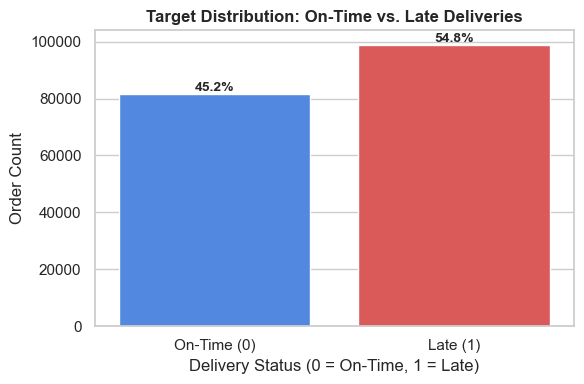

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))

# Bar chart of target variable
ax = sns.countplot(
    data=df,
    x="is_late",
    palette=["#3b82f6", "#ef4444"],
    hue="is_late",
    legend=False,
)

plt.title("Target Distribution: On-Time vs. Late Deliveries", fontsize=12, fontweight="bold")
plt.xlabel("Delivery Status (0 = On-Time, 1 = Late)")
plt.ylabel("Order Count")
plt.xticks(ticks=[0, 1], labels=["On-Time (0)", "Late (1)"])

# Add exact percentage labels on top of the bars
total = len(df)
for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## Late Rate Breakdown by Shipping Mode & Market



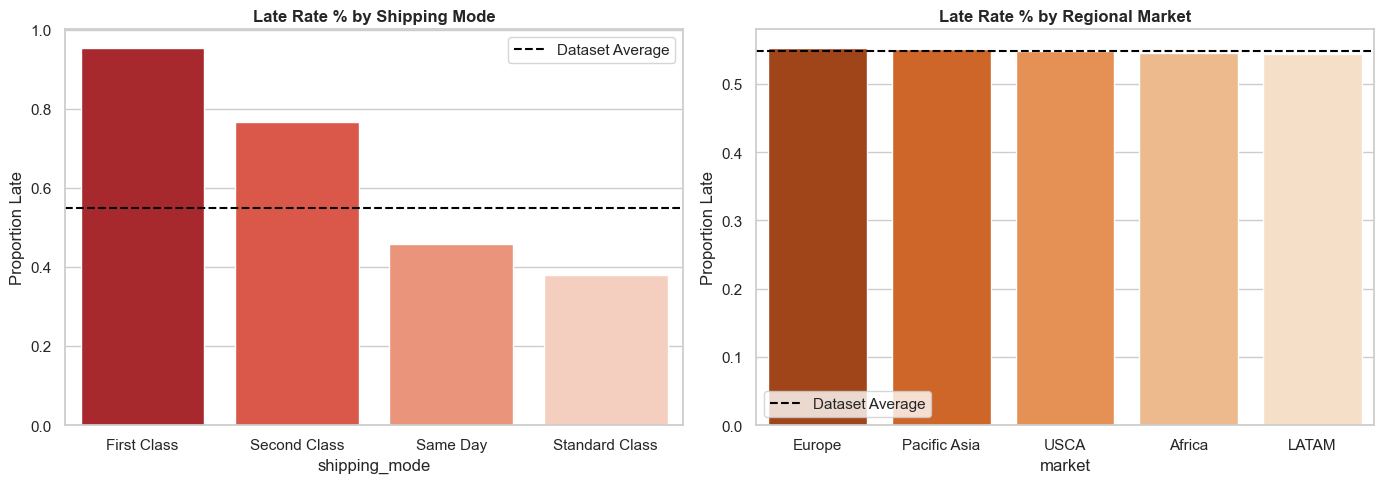

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Delay Rate by Shipping Mode
mode_risk = (
    df.groupby("shipping_mode")["is_late"]
    .mean()
    .reset_index()
    .sort_values(by="is_late", ascending=False)
)

sns.barplot(
    data=mode_risk,
    x="shipping_mode",
    y="is_late",
    ax=axes[0],
    palette="Reds_r",
    hue="shipping_mode",
    legend=False,
)
axes[0].axhline(df["is_late"].mean(), color="black", linestyle="--", label="Dataset Average")
axes[0].set_title("Late Rate % by Shipping Mode", fontweight="bold")
axes[0].set_ylabel("Proportion Late")
axes[0].legend()

# Plot 2: Delay Rate by Market
market_risk = (
    df.groupby("market")["is_late"]
    .mean()
    .reset_index()
    .sort_values(by="is_late", ascending=False)
)

sns.barplot(
    data=market_risk,
    x="market",
    y="is_late",
    ax=axes[1],
    palette="Oranges_r",
    hue="market",
    legend=False,
)
axes[1].axhline(df["is_late"].mean(), color="black", linestyle="--", label="Dataset Average")
axes[1].set_title("Late Rate % by Regional Market", fontweight="bold")
axes[1].set_ylabel("Proportion Late")
axes[1].legend()

plt.tight_layout()
plt.show()

## Scheduled Shipping Time vs. Delay Risk

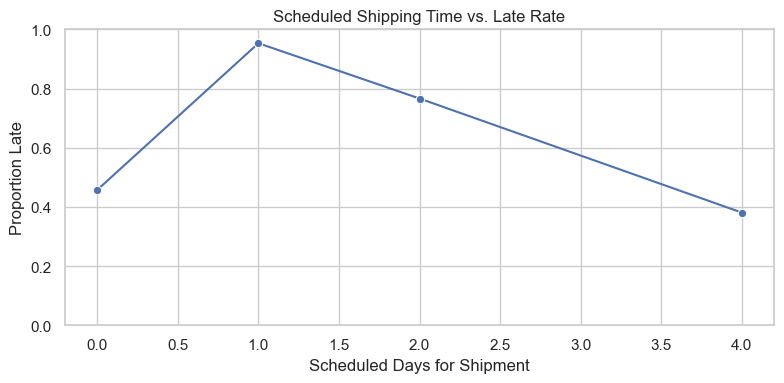

In [4]:
plt.figure(figsize=(8, 4))

# Scheduled Days vs Late Proportion
scheduled_risk = (
    df.groupby("scheduled_days")["is_late"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=scheduled_risk,
    x="scheduled_days",
    y="is_late",
    marker="o",
)

plt.title("Scheduled Shipping Time vs. Late Rate")
plt.xlabel("Scheduled Days for Shipment")
plt.ylabel("Proportion Late")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Key EDA Findings & Feature Hypotheses

Our data visualisation confirms the patterns previously identified in descriptive analysis using Power BI and provides a strong foundation for model feature selection:

1. **Target Class Balance:** 
   * The dataset target `is_late` is well-balanced (~55% late vs. ~45% on-time). No severe class imbalance techniques (e.g., SMOTE, class weighting) are required.

2. **Shipping Mode as a Dominant Feature:** 
   * **First Class** shipping demonstrates an extreme delay rate (>90%), whereas **Standard Class** exhibits significantly lower late rates (~38%). This variance makes `shipping_mode` a primary candidate for top feature importance in tree-based splits.

3. **Regional Market Stability:** 
   * Market regions (Europe, LATAM, Pacific Asia, USCA, Africa) display relatively uniform late rates near the global average. While included as a baseline feature, market alone may carry lower predictive weight compared to fulfillment parameters.

4. **Scheduled Delivery Window Impact:** 
   * A strong inverse correlation exists between promised lead times and delay rates: 1-day scheduled shipments suffer a ~90% failure rate, which gradually drops to ~40% as scheduled days increase to 4. 

---

## EDA stage-2

After exploring the top level features, in stage 2 of data exploaration, I want to explore Granular Regions & Product Categories, which may turn out to be important features for modelling.

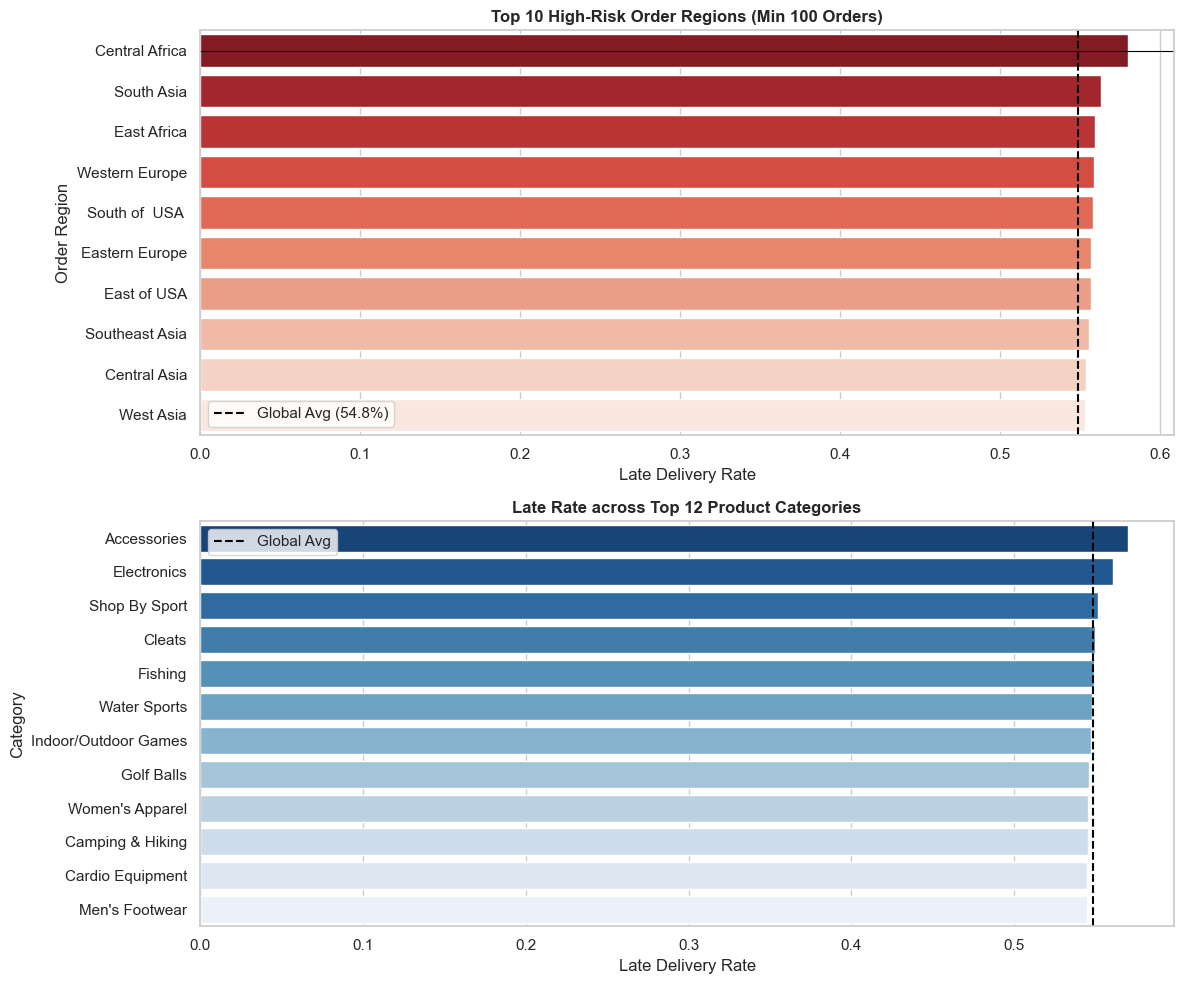

In [5]:

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 1. Top 10 Regions with Highest Delay Risk
region_risk = (
    df.groupby("order_region")["is_late"]
    .agg(["mean", "count"])
    .query("count > 100")
    .sort_values(by="mean", ascending=False)
    .head(10)
    .reset_index()
)

sns.barplot(
    data=region_risk,
    y="order_region",
    x="mean",
    ax=axes[0],
    palette="Reds_r",
    hue="order_region",
    legend=False,
)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(
    df["is_late"].mean(),
    color="black",
    linestyle="--",
    label=f'Global Avg ({df["is_late"].mean():.1%})',
)
axes[0].set_title(
    "Top 10 High-Risk Order Regions (Min 100 Orders)", fontweight="bold"
)
axes[0].set_xlabel("Late Delivery Rate")
axes[0].set_ylabel("Order Region")
axes[0].legend()

# 2. Product Category Risk (Top 12 Most Frequent Categories)
top_categories = df["category_name"].value_counts().head(12).index
cat_risk = (
    df[df["category_name"].isin(top_categories)]
    .groupby("category_name")["is_late"]
    .mean()
    .reset_index()
    .sort_values(by="is_late", ascending=False)
)

sns.barplot(
    data=cat_risk,
    y="category_name",
    x="is_late",
    ax=axes[1],
    palette="Blues_r",
    hue="category_name",
    legend=False,
)
axes[1].axvline(
    df["is_late"].mean(),
    color="black",
    linestyle="--",
    label="Global Avg",
)
axes[1].set_title(
    "Late Rate across Top 12 Product Categories", fontweight="bold"
)
axes[1].set_xlabel("Late Delivery Rate")
axes[1].set_ylabel("Category")
axes[1].legend()

plt.tight_layout()
plt.show()

### Financial Drivers - Product Price & Order Sales vs. Delay

Checking if order value or product pricing impacts delivery delay risk.

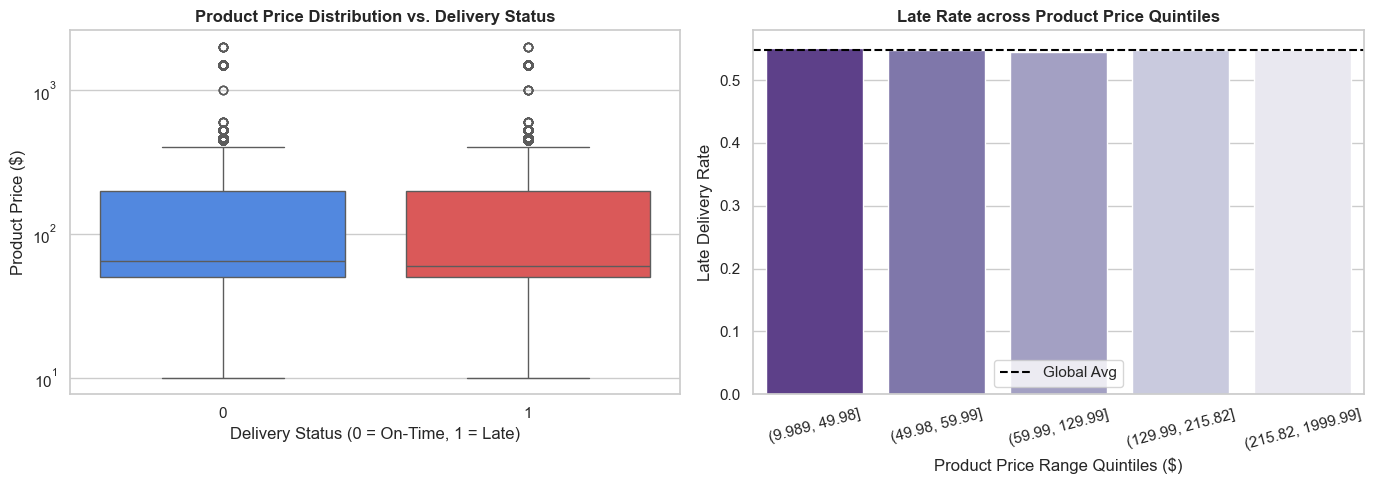

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Product Price Distribution by Delivery Status
sns.boxplot(
    data=df,
    x="is_late",
    y="product_price",  # Use 'total_sales' or 'order_item_total' if product_price isn't in your view
    ax=axes[0],
    palette=["#3b82f6", "#ef4444"],
    hue="is_late",
    legend=False,
)
axes[0].set_title("Product Price Distribution vs. Delivery Status", fontweight="bold")
axes[0].set_xlabel("Delivery Status (0 = On-Time, 1 = Late)")
axes[0].set_ylabel("Product Price ($)")
axes[0].set_yscale("log")  # Using log scale to handle price outliers cleanly

# 2. Binned Sales Price vs. Late Rate
df["price_bin"] = pd.qcut(df["product_price"], q=5, duplicates="drop")
price_risk = (
    df.groupby("price_bin", observed=False)["is_late"]
    .mean()
    .reset_index()
)
price_risk["price_bin"] = price_risk["price_bin"].astype(str)

sns.barplot(
    data=price_risk,
    x="price_bin",
    y="is_late",
    ax=axes[1],
    palette="Purples_r",
    hue="price_bin",
    legend=False,
)
axes[1].axhline(df["is_late"].mean(), color="black", linestyle="--", label="Global Avg")
axes[1].set_title("Late Rate across Product Price Quintiles", fontweight="bold")
axes[1].set_xlabel("Product Price Range Quintiles ($)")
axes[1].set_ylabel("Late Delivery Rate")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()

**Product Price Neutrality:**
   * Analysis across price quintiles ($9.99 to $1,999.99) shows uniform delay rates (~54.8%) identical to the global baseline. Product price does not independently influence fulfillment speed.

### Visualising Temporal patterns

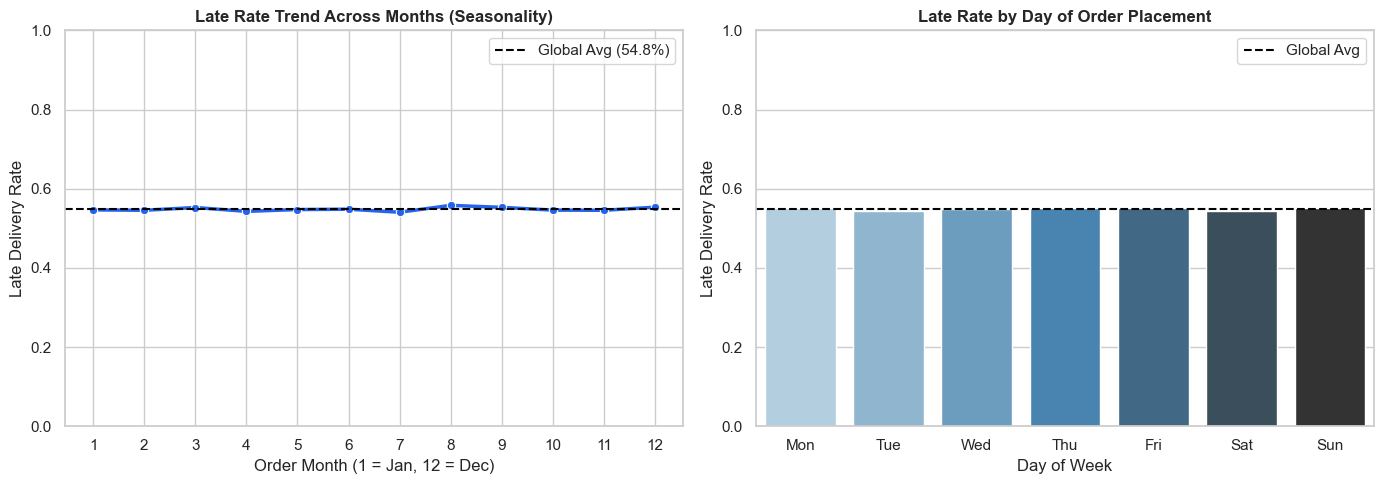

In [7]:
# Extract Temporal Features from order_date first
df["order_date"] = pd.to_datetime(df["order_date"])
df["order_dow"] = df["order_date"].dt.dayofweek  # Day of week (0=Mon, 6=Sun)
df["order_month"] = df["order_date"].dt.month  # Seasonality / Month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Late Delivery Rate by Month (1-12)
month_risk = df.groupby("order_month")["is_late"].mean().reset_index()

sns.lineplot(
    data=month_risk,
    x="order_month",
    y="is_late",
    marker="o",
    color="#2563eb",
    linewidth=2.5,
    ax=axes[0],
)
axes[0].axhline(
    df["is_late"].mean(),
    color="black",
    linestyle="--",
    label=f'Global Avg ({df["is_late"].mean():.1%})',
)
axes[0].set_title(
    "Late Rate Trend Across Months (Seasonality)", fontweight="bold"
)
axes[0].set_xlabel("Order Month (1 = Jan, 12 = Dec)")
axes[0].set_ylabel("Late Delivery Rate")
axes[0].set_xticks(range(1, 13))
axes[0].set_ylim(0, 1)
axes[0].legend()

# Late Delivery Rate by Day of Week
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_risk = df.groupby("order_dow")["is_late"].mean().reset_index()

sns.barplot(
    data=dow_risk,
    x="order_dow",
    y="is_late",
    palette="Blues_d",
    hue="order_dow",
    legend=False,
    ax=axes[1],
)
axes[1].axhline(
    df["is_late"].mean(), color="black", linestyle="--", label="Global Avg"
)
axes[1].set_title(
    "Late Rate by Day of Order Placement", fontweight="bold"
)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Late Delivery Rate")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_labels)
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

# Preprocessing and data pipeline

We will now prepare our feature matrix ($X$) and target vector ($y$). 

* **Feature Selection:** We should exclude data leakage features (`days_for_shipping_real`, `delivery_status`, `order_status`) and non-predictive metadata.
* **Excluded features:** Random primary keys (`order_id` , `order_item_id` / `customer_id`) and high cardinality values(`order_city / product_name`), on which when one hot encoder is applied, it creates thousands of sparse binary columns, drastically increasing memory usage without adding meaningful signal, and post fulfillment financials like `profit` are excluded from the feature matrix.
* **Train/Test Split:** Perform an 80/20 stratified split to preserve target class balance across sets.
* **Transformation:** Use a `ColumnTransformer` applying `OneHotEncoder` (with `handle_unknown='ignore'`) for categorical predictors, passing numeric features straight through.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


# Expanded Feature Set
feature_cols = [
    # Categorical Logistics & Geography
    "shipping_mode",
    "market",
    "order_region",
    "order_country",
    "category_name",
    # Operational & Lead Time
    "scheduled_days",
    # Order Details & Volume
    "quantity",
    "product_price",
    "total_sales",
    # Temporal Features
    "order_dow",
    "order_month",
]

X = df[feature_cols]
y = df["is_late"]


# Stratified Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Categorical vs Numeric Split
categorical_cols = [
    "shipping_mode",
    "market",
    "order_region",
    "order_country",
    "category_name",
]

numeric_cols = [
    "scheduled_days",
    "quantity",
    "product_price",
    "total_sales",
    "order_dow",
    "order_month",
]

# Build Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_cols,
        ),
    ]
)

# Transform Feature Sets
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"Original Train Matrix: {X_train.shape}")
print(f"Processed Feature Matrix: {X_train_prep.shape}")

Original Train Matrix: (144415, 11)
Processed Feature Matrix: (144415, 252)


# Model Training

To identify the optimal predictive model for delivery delays, we evaluate three distinct model architectures using **5-Fold Stratified Cross-Validation**:

1. **Baseline Model:** Random Forest Classifier
2. **Gradient Boosting:** LightGBM / XGBoost
3. **Deep Learning:** Multi-Layer Perceptron (Neural Network)

Stratified K-Fold CV ensures each fold preserves the target class ratio (~55% late), providing a robust, variance-free evaluation across the dataset. Moreover, GridSearchCV helps tune the hyperparameters effectively.




## Baseline Model: Random Forest Classifier

As a baseline model, we use Random forest classifier:

We use `GridSearchCV`, to tune the parameters such as, `n_estimators, max_depth and min_samples_split` and then train the model on the chosen parameters and then test it on the Test data.

I am using a sequential tuning method, i.e., tuning one parameter at a time and then fixing it to tune next ones.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

param_grid = {
    "n_estimators": [100, 200,300,400,500]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Setup GridSearchCV optimizing for ROC-AUC
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1, max_depth =10),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True,
)

print("Starting 5-Fold Cross-Validation Grid Search...")
grid_search.fit(X_train_prep, y_train)

print("\n=== Best Parameters Found ===")
print(grid_search.best_params_)
print(f"Best CV Mean ROC-AUC: {grid_search.best_score_:.4f}")


Starting 5-Fold Cross-Validation Grid Search...

=== Best Parameters Found ===
{'n_estimators': 400}
Best CV Mean ROC-AUC: 0.7370


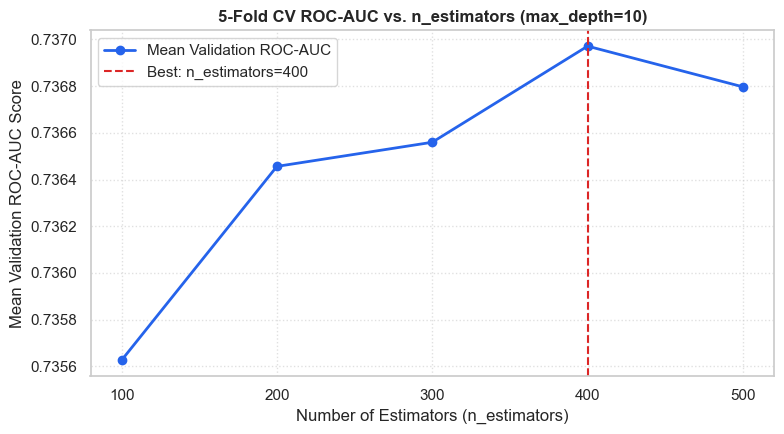

In [13]:
cv_results = pd.DataFrame(grid_search.cv_results_)

# Extract x and y values
x_values = cv_results["param_n_estimators"].astype(int)
y_values = cv_results["mean_test_score"]
y_std = cv_results["std_test_score"]

# Plot
plt.figure(figsize=(8, 4.5))
plt.plot(
    x_values,
    y_values,
    marker="o",
    color="#2563eb",
    linewidth=2,
    label="Mean Validation ROC-AUC",
)

best_n = grid_search.best_params_["n_estimators"]
plt.axvline(
    x=best_n,
    color="#dc2626",
    linestyle="--",
    label=f"Best: n_estimators={best_n}",
)

plt.title("5-Fold CV ROC-AUC vs. n_estimators (max_depth=10)", fontweight="bold")
plt.xlabel("Number of Estimators (n_estimators)")
plt.ylabel("Mean Validation ROC-AUC Score")
plt.xticks([100, 200, 300, 400, 500])
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Now, tuning `max_depth and min_samples_split`

In [14]:

param_grid = {
    "max_depth": [5, 10, 20, 30, 40]}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Setup GridSearchCV optimizing for ROC-AUC
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=400),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True,
)

print("Starting 5-Fold Cross-Validation Grid Search...")
grid_search.fit(X_train_prep, y_train)

print("\n=== Best Parameters Found ===")
print(grid_search.best_params_)
print(f"Best CV Mean ROC-AUC: {grid_search.best_score_:.4f}")

Starting 5-Fold Cross-Validation Grid Search...

=== Best Parameters Found ===
{'max_depth': 30}
Best CV Mean ROC-AUC: 0.7450


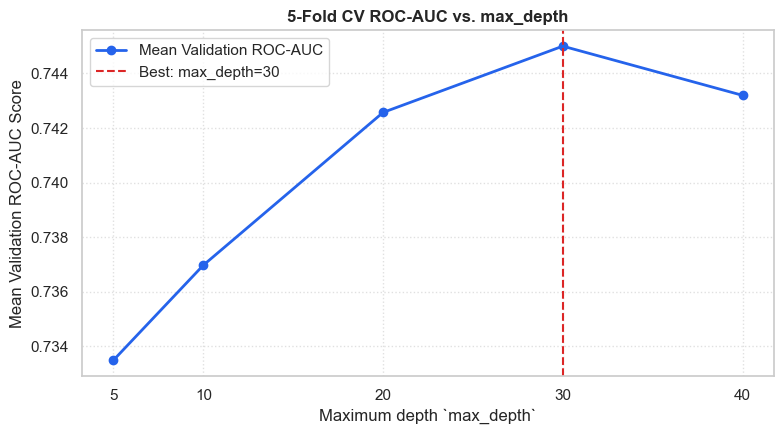

In [16]:
cv_results2 = pd.DataFrame(grid_search.cv_results_)

# Extract x and y values
x_values = cv_results2["param_max_depth"].astype(int)
y_values = cv_results2["mean_test_score"]
y_std = cv_results2["std_test_score"]

# Plot
plt.figure(figsize=(8, 4.5))
plt.plot(
    x_values,
    y_values,
    marker="o",
    color="#2563eb",
    linewidth=2,
    label="Mean Validation ROC-AUC",
)

best_m = grid_search.best_params_["max_depth"]
plt.axvline(
    x=best_m,
    color="#dc2626",
    linestyle="--",
    label=f"Best: max_depth={best_m}",
)

plt.title("5-Fold CV ROC-AUC vs. max_depth", fontweight="bold")
plt.xlabel(f"Maximum depth `max_depth`")
plt.ylabel("Mean Validation ROC-AUC Score")
plt.xticks([5,10,20,30,40])
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Starting 5-Fold Cross-Validation Grid Search...

=== Best Parameters Found ===
{'min_samples_split': 6}
Best CV Mean ROC-AUC: 0.7450


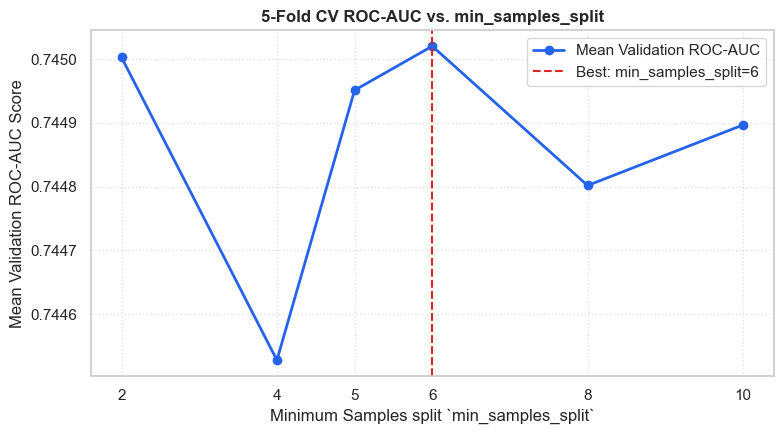

In [18]:

param_grid3 = {
    "min_samples_split": [2,4,5,6,8,10]}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Setup GridSearchCV optimizing for ROC-AUC
grid_search3 = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=400, max_depth=30),
    param_grid=param_grid3,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True,
)

print("Starting 5-Fold Cross-Validation Grid Search...")
grid_search3.fit(X_train_prep, y_train)

print("\n=== Best Parameters Found ===")
print(grid_search3.best_params_)
print(f"Best CV Mean ROC-AUC: {grid_search3.best_score_:.4f}")


cv_results3 = pd.DataFrame(grid_search3.cv_results_)

# Extract x and y values
x_values = cv_results3["param_min_samples_split"].astype(int)
y_values = cv_results3["mean_test_score"]
y_std = cv_results3["std_test_score"]

# Plot
plt.figure(figsize=(8, 4.5))
plt.plot(
    x_values,
    y_values,
    marker="o",
    color="#2563eb",
    linewidth=2,
    label="Mean Validation ROC-AUC",
)

best_mm = grid_search3.best_params_["min_samples_split"]
plt.axvline(
    x=best_mm,
    color="#dc2626",
    linestyle="--",
    label=f"Best: min_samples_split={best_mm}",
)

plt.title("5-Fold CV ROC-AUC vs. min_samples_split", fontweight="bold")
plt.xlabel(f"Minimum Samples split `min_samples_split`")
plt.ylabel("Mean Validation ROC-AUC Score")
plt.xticks([2,4,5,6,8,10])
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()



### The final training and testing

Final Tuned Random Forest: Test Set Performance
ROC-AUC Score: 0.7490

              precision    recall  f1-score   support

 On-Time (0)       0.62      0.86      0.72     16308
    Late (1)       0.83      0.56      0.67     19796

    accuracy                           0.70     36104
   macro avg       0.73      0.71      0.70     36104
weighted avg       0.74      0.70      0.69     36104



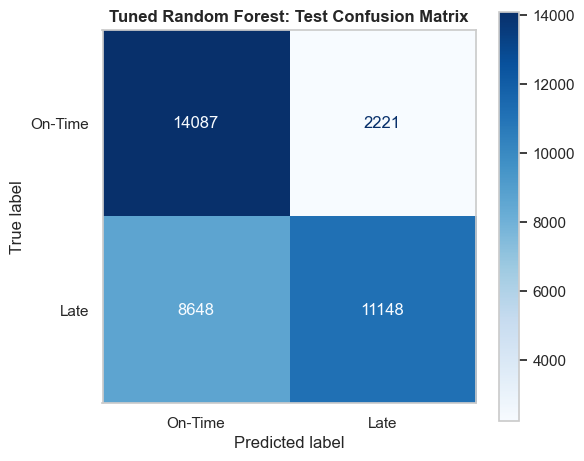

In [ ]:

# Extract the final fitted model from last GridSearch execution
#final_rf_model = grid_search3.best_estimator_ ----- Method 1 
final_rf_model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=400, max_depth =30, min_samples_split=6) # Method 2 
# Generate predictions on held-out test data

# It is to be noted that Method 1 and method 2 give same results..

final_rf_model.fit(X_train_prep, y_train)
y_pred_rf = final_rf_model.predict(X_test_prep)
y_proba_rf = final_rf_model.predict_proba(X_test_prep)[:, 1]

# Compute test ROC-AUC score
test_roc_auc = roc_auc_score(y_test, y_proba_rf)

print("Final Tuned Random Forest: Test Set Performance")
print(f"ROC-AUC Score: {test_roc_auc:.4f}\n")
print(
    classification_report(
        y_test, y_pred_rf, target_names=["On-Time (0)", "Late (1)"]
    )
)

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["On-Time", "Late"],
    cmap="Blues",
    ax=ax,
)
plt.title("Tuned Random Forest: Test Confusion Matrix", fontweight="bold")
plt.grid(False)
plt.tight_layout()
plt.show()

### Summary: Random Forest Baseline Performance

The sequentially tuned Random Forest classifier (`n_estimators=400`, `max_depth=10`, `min_samples_split=6`) establishes our project benchmark:

* **ROC-AUC Score:** `0.7490`
* **Overall Accuracy:** `70.0%`
* **Late Class Precision:** `0.83` (83% of predicted late deliveries are actual delays)
* **Late Class Recall:** `0.56` (Captures 56% of total operational delays; 8,648 false negatives)

#### Key Takeaway for Next Models
The baseline handles precision well but suffers from conservative recall on the minority/positive class. Our goal for **LightGBM** and **Neural Network** is to push the ROC-AUC beyond `0.75` and improve late-delivery recall without sacrificing precision.